
## 1. استيراد المكتبات وتحميل البيانات


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("online_retail_cleaned.csv")


df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth,Day,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,15.30,2010-12,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,2010-12,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,22.00,2010-12,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,2010-12,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,2010-12,1,Wednesday,8


##  تحليل أداء المنتجات (Product Performance)

(Top 10 Products) 

In [2]:
product_analysis = df.groupby('Description').agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).sort_values(ascending=False, by='TotalPrice').reset_index()

# استخراج أفضل 10 منتجات
top_10_products = product_analysis.head(10)
top_10_products

,Description,Quantity,TotalPrice
0,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
1,WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10
2,JUMBO BAG RED RETROSPOT,46078,85040.54
3,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
4,PARTY BUNTING,15271,68655.75
5,ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03
6,RABBIT NIGHT LIGHT,27153,51251.24
7,CHILLI LIGHTS,9631,46078.21
8,PAPER CHAIN KIT 50'S CHRISTMAS,15591,42584.13
9,BLACK RECORD COVER FRAME,11394,38993.58


C:\Users\knaria\AppData\Local\Temp\ipykernel_7516\1698159983.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_products, x='TotalPrice', y='Description', palette='viridis')


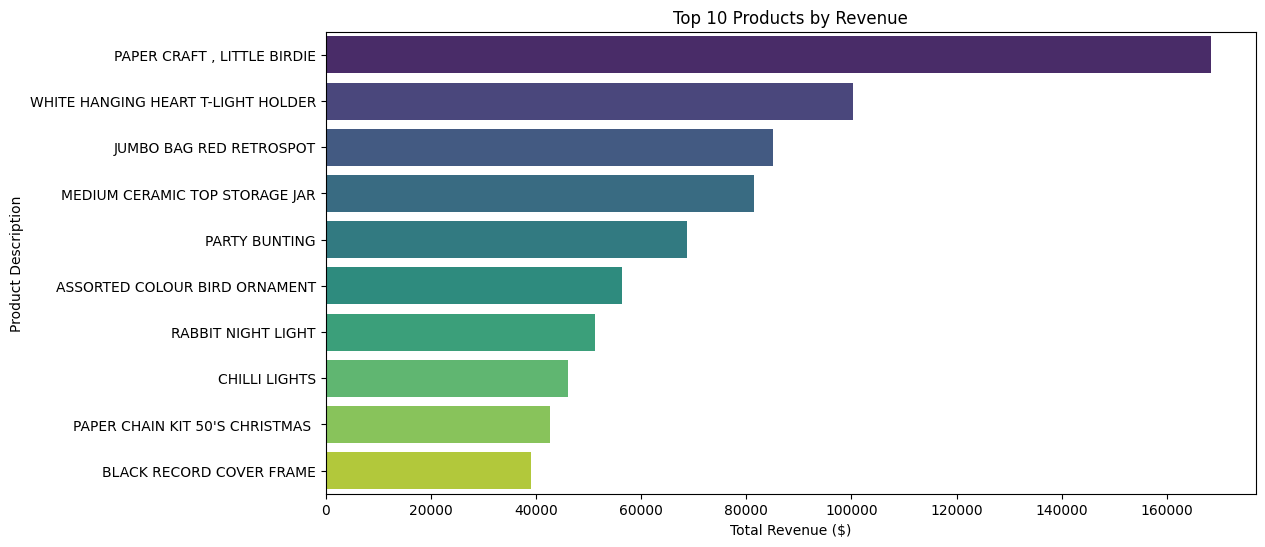

In [10]:
# رسم أعلى 10 منتجات مبيعاً باستخدام المتغير top_10_products
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_products, x='TotalPrice', y='Description', palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Description')
plt.show()

##  تحليل سلوك العملاء (Customer Behavior)



In [3]:
# تجميع البيانات حسب رقم العميل
customer_analysis = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',  
    'TotalPrice': 'sum'      
}).sort_values(ascending=False, by='TotalPrice').reset_index()

# إعادة تسمية الأعمدة لتكون أكثر وضوحاً
customer_analysis.rename(columns={'InvoiceNo': 'Total_Orders', 'TotalPrice': 'Total_Spent'}, inplace=True)

# استخراج أفضل 10 عملاء
top_10_customers = customer_analysis.head(10)
top_10_customers

,CustomerID,Total_Orders,Total_Spent
0,14646,73,258710.77
1,18102,55,192580.17
2,17450,42,176527.17
3,16446,2,168472.50
4,12415,20,111675.13
5,14911,195,109725.20
6,14156,52,91441.68
7,17511,31,82628.52
8,12346,1,77183.60
9,16029,62,71848.29


C:\Users\knaria\AppData\Local\Temp\ipykernel_7516\3480138157.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_customers_plot, x='CustomerID', y='Total_Spent', palette='magma')


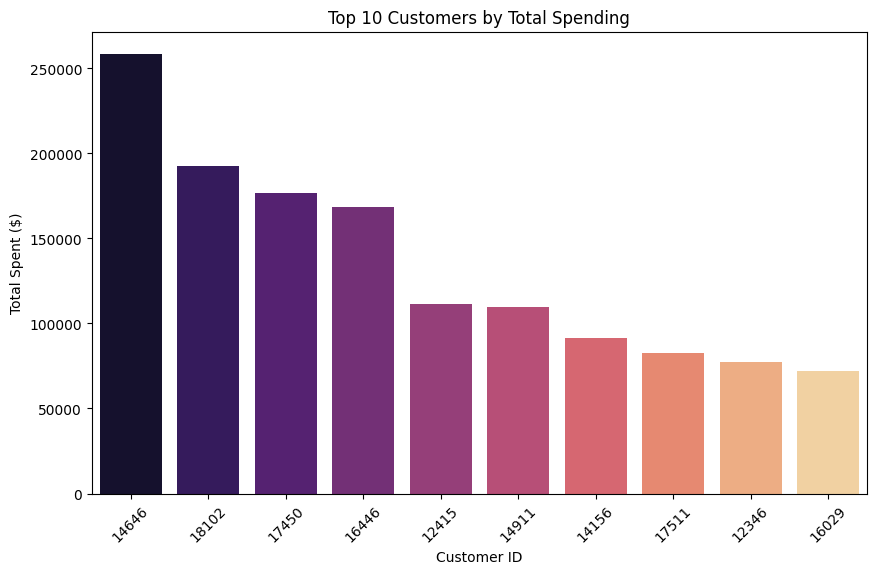

In [11]:
# رسم كبار العملاء باستخدام المتغير top_10_customers
plt.figure(figsize=(10, 6))

# تحويل ID العميل لنص (String) عشان الرسمة تطلع منظمة وما يتعاملش معاها كأرقام حسابية
top_10_customers_plot = top_10_customers.copy()
top_10_customers_plot['CustomerID'] = top_10_customers_plot['CustomerID'].astype(str)

sns.barplot(data=top_10_customers_plot, x='CustomerID', y='Total_Spent', palette='magma')
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spent ($)')
plt.xticks(rotation=45)
plt.show()

##  التحليل الجغرافي للمبيعات (Country Insights)


In [4]:
# تجميع المبيعات وعدد العملاء حسب الدولة
country_analysis = df.groupby('Country').agg({
    'TotalPrice': 'sum',
    'CustomerID': 'nunique'
}).sort_values(ascending=False, by='TotalPrice').reset_index()

country_analysis.rename(columns={'TotalPrice': 'Total_Revenue', 'CustomerID': 'Unique_Customers'}, inplace=True)

# عرض أداء أعلى 10 دول
top_10_countries = country_analysis.head(10)
top_10_countries

,Country,Total_Revenue,Unique_Customers
0,United Kingdom,6080568.114,3888
1,Netherlands,262929.090,8
2,EIRE,203972.540,3
3,Germany,170208.200,93
4,France,159266.060,87
5,Australia,123700.960,9
6,Spain,45571.260,30
7,Switzerland,44014.600,21
8,Sweden,36218.030,8
9,Japan,34781.470,8


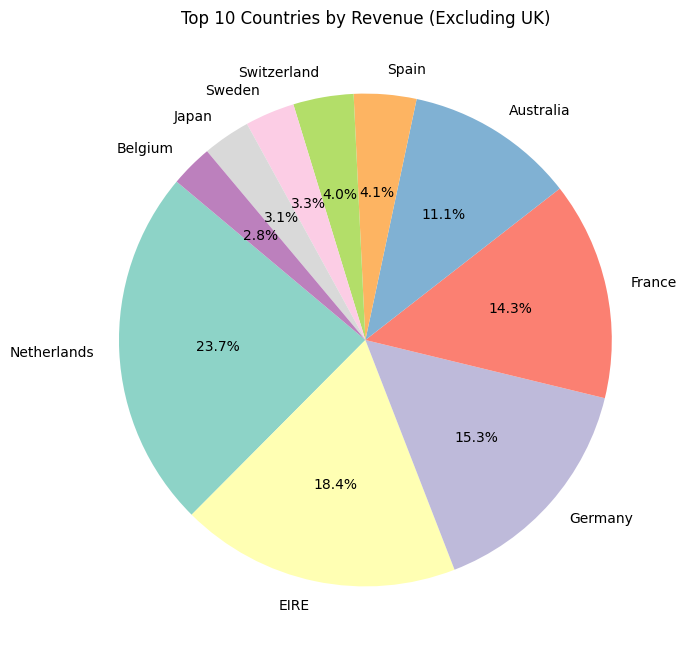

In [12]:
country_pie_data = country_analysis[country_analysis['Country'] != 'United Kingdom'].head(10)

plt.figure(figsize=(10, 8))
plt.pie(country_pie_data['Total_Revenue'], 
        labels=country_pie_data['Country'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('Set3'))

plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.show()

##  تحليل سلة المشتريات (Basket Analysis)


In [5]:
invoice_summary = df.groupby('InvoiceNo').agg({
    'TotalPrice': 'sum',
    'Quantity': 'sum'
}).reset_index()

# حساب المتوسطات
average_order_value = invoice_summary['TotalPrice'].mean()
average_order_size = invoice_summary['Quantity'].mean()

# تحويل النتائج إلى DataFrame لسهولة تصديرها أو عرضها
kpi_df = pd.DataFrame({
    'Metric': ['Average Order Value (AOV)', 'Average Items Per Order'],
    'Value': [round(average_order_value, 2), round(average_order_size, 2)]
})

kpi_df

,Metric,Value
0,Average Order Value (AOV),407.00
1,Average Items Per Order,277.58


C:\Users\knaria\AppData\Local\Temp\ipykernel_7516\3090085377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi_df, x='Metric', y='Value', palette='Pastel1')


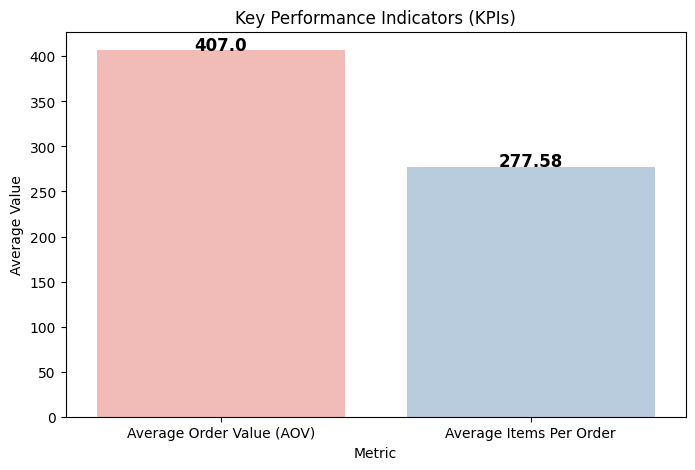

In [13]:
# رسم المؤشرات الرئيسية باستخدام المتغير kpi_df
plt.figure(figsize=(8, 5))
sns.barplot(data=kpi_df, x='Metric', y='Value', palette='Pastel1')

# إضافة الأرقام فوق الأعمدة للتوضيح
for i, value in enumerate(kpi_df['Value']):
    plt.text(i, value + 0.1, str(value), ha='center', fontsize=12, fontweight='bold')

plt.title('Key Performance Indicators (KPIs)')
plt.ylabel('Average Value')
plt.show()

##  تصدير البيانات الجاهزة (Data Export)



In [ ]:
# حفظ البيانات في ملفات CSV 
top_10_products.to_csv("Data\top_10_products.csv", index=False)
customer_analysis.to_csv("Data\customer_behavior_summary.csv", index=False)
country_analysis.to_csv("Data\country_sales_summary.csv", index=False)
kpi_df.to_csv("Data\sales_kpis.csv", index=False)

print("تم تصدير جميع ملفات  بنجاح")

تم تصدير جميع ملفات  بنجاح
